In [8]:
## MC protocol single gs and single satellite general positions and trajectories
## to be used for verification of longer time dynamics

import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def generate_rotation_approx(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz
    
    M = np.identity(3) + angle*L #+ 0.5*(angle**2)*L*L 

    return np.matrix(M)

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def evolve_vector_approx(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation_approx(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

def correlations(t_ig, t_is, t_ig1, t_is1, dist_0, v_rel_radial1, i):

        t_is = t_is - (i + math.floor(dist_0/(c-v_rel_radial1)/dt)) 
        t_ig1 = t_ig1 - (i + math.floor(dist_0/(c-v_rel_radial1)/dt)) 
        g = len(np.intersect1d(t_is,t_ig))
        g1 = len(np.intersect1d(t_is1,t_ig1))

        if i%1000 == 0:
            print('step',i,'of',math.floor(corr_range/dt))

        return g, g1
    
def SNR_t(corr,i): 
        
        a = np.array(corr[:,0])
        b = np.array(corr[:,1])
        n1_mean = np.mean(a)
        n2_mean = np.mean(b)
        n1_std = np.std(a)
        n2_std = np.std(b)

         
        snr1 = (a[i] - n1_mean)/n1_std
        snr2 = (b[i] - n2_mean)/n2_std
        
        if snr1<0 or n1_std==0:
            snr1=0
        if snr2<0 or n2_std==0:
            snr2=0
        
        return snr1, snr2
    
def run_protocol(gs_0, sat_0, dist_0, T, v_rel_radial1, t):
        
    # protocol run parameters
    
    noise_rate_gs = 1e5
    noise_rate_sat = 1e5
    pair_rate = 1e7
    
    # overall and relative clock offsets

    offset = 5e-6
    delta = 3e-6

    dt = 1e-10
    steps = math.floor(T/dt)
    
    
    if t%1e4==0:
        print(str(t*dt)+'of'+ str(T))
    
    gs = evolve_vector_approx(gs_0, axis_earth, Om, t*dt)
    sat = evolve_vector_approx(sat_0, axis_sat, om, t*dt)

    dist = dst(gs, sat)

    eff_gs_sat = eta(dist, h, 0.6, 0.1, 0.25)
    eff_sat_gs = eta(dist, h, 0.1, 0.6, 0.25)
    
    t_ig = 0; t_is = 0; t_ig1 = 0; t_is1 = 0;

    #stray counts/noise at gs

    if random.randrange(math.floor(steps/noise_rate_gs/T)) == 1:
        t_ig1 = t + math.floor(dist_0/(c-v_rel_radial1)/dt)


    #gs-sat correlation
    if random.randrange(math.floor(steps/pair_rate/T)) == 1:

        t_ig = t

        if random.random()<=eff_gs1_sat:

            t_is = math.floor((offset + t*dt + delta + dist/(c-v_rel_radial1))/dt)

    #stray counts/noise at sat

    if random.randrange(math.floor(steps/noise_rate_sat/T)) == 1:
        t_is = t + math.floor(dist_0/(c-v_rel_radial1)/dt)


    #sat-gs correlation
    if random.randrange(math.floor(steps/pair_rate/T)) == 1:

        t_is1 = t

        if random.random()<=eff_sat_gs1:

            t_ig1 = math.floor((offset + t*dt - delta + dist/(c-v_rel_radial1))/dt)

    return t_ig, t_is, t_ig1, t_is1



#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600


#two ground stations
gs1_0 = generate_point(R, 85*np.pi/180, 10*np.pi/180)
gs2_0 = generate_point(R, 90*np.pi/180, 10*np.pi/180)
axis_earth = np.array([0,0,1]) #z-axis


#satellite
sat_0 = generate_point(R+h, 90*np.pi/180, 0*np.pi/180)

axis_sat = np.array([0,1,0]) #x-axis

T_big = 1
dT = 1
bigsteps = math.floor(T_big/dT)

# protocol run parameters
    
noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7

dt = 1e-10

# overall and relative clock offsets

offset = 5e-6
delta = 3e-6

t_gb = 0
gs1 = evolve_vector(gs1_0, axis_earth, Om, t_gb*dT)
gs2 = evolve_vector(gs2_0, axis_earth, Om, t_gb*dT)
sat = evolve_vector(sat_0, axis_sat, om, t_gb*dT)

#gs velocities
v_gs1 = np.cross(gs1, Om*axis_earth)
v_gs2 = np.cross(gs2, Om*axis_earth)

#satellite velocity
v_sat = np.cross(sat, om*axis_sat)

#radial relative velocities
v_rel_radial1 = np.dot(np.subtract(v_sat, v_gs1), np.subtract(sat, gs1)/np.linalg.norm(np.subtract(sat, gs1)))
v_rel_radial2 = np.dot(np.subtract(v_sat, v_gs2), np.subtract(sat, gs2)/np.linalg.norm(np.subtract(sat, gs2)))

#t_shift = t_bin/v_rel

T1 = 1e-4 #dt/abs(v_rel_radial1/c + (v_rel_radial1/c)**2)
T2 = 1e-4 #dt/abs(v_rel_radial2/c + (v_rel_radial2/c)**2)

angle = math.acos(np.dot(gs1,sat)/np.linalg.norm(gs1)/np.linalg.norm(sat))*180/np.pi

dist1 = dst(gs1, sat)
dist2 = dst(gs2, sat)

eff_gs1_sat = eta(dist1, h, 0.6, 0.1, 0.25)
eff_sat_gs1 = eta(dist1, h, 0.1, 0.6, 0.25)
eff_gs2_sat = eta(dist2, h, 0.6, 0.1, 0.25)
eff_sat_gs2 = eta(dist2, h, 0.1, 0.6, 0.25)

counts = [math.floor(eff_gs1_sat*pair_rate*T1), math.floor(eff_sat_gs1*pair_rate*T1), math.floor(eff_gs2_sat*pair_rate*T2), math.floor(eff_sat_gs2*pair_rate*T2)]

t_ig = np.array([0]); t_ig1 = np.array([0]);
t_is = np.array([0]); t_is1 = np.array([0]);
x = time.time()
t_stamps = Parallel(n_jobs=20)(delayed(run_protocol)(gs1, sat, dist1, T1, v_rel_radial1, t) for t in range(math.floor(T1/dt)))
t_stamps = np.array(t_stamps)
print(time.time()-x)

t_ig = np.unique(t_stamps[:,0])[1:-1]
t_is = np.unique(t_stamps[:,1])[1:-1]
t_ig1 = np.unique(t_stamps[:,2])[1:-1]
t_is1 = np.unique(t_stamps[:,3])[1:-1]

#correlations

corr_range = 1e-5;

i_array = np.array([i for i in range(math.floor(corr_range/dt))])
x = time.time()
g = Parallel(n_jobs=10)(delayed(correlations)(t_ig, t_is, t_ig1, t_is1, dist1, v_rel_radial1, i) for i in i_array)
g = np.array(g)
print(time.time()-x)
#SNR

SNR = Parallel(n_jobs=25)(delayed(SNR_t)(g,i) for i in i_array)
SNR = np.array(SNR)


64.55825448036194
7.9817588329315186


In [9]:
v_rel_radial1

-3460.1941304217835

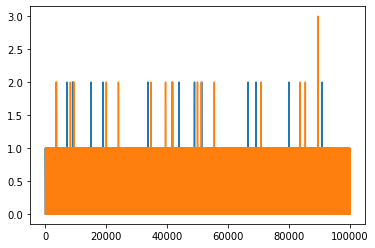

In [10]:
plt.plot(i_array, g)

In [ ]:
## MC protocol single gs and single satellite general positions and trajectories
## to be used for verification of longer time dynamics

import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def generate_rotation_approx(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz
    
    M = np.identity(3) + angle*L #+ 0.5*(angle**2)*L*L 

    return np.matrix(M)

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def evolve_vector_approx(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation_approx(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5

def eta(L, h, r, R, eff):
    lam = 810e-9;
    eta_zen = 0.5;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    eta_atm2 = eta_zen**secZ;

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter

    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance

    efficiency = eta_sg * eta_atm2 * eff;
    
    return efficiency

def correlations(t_ig, t_is, t_ig1, t_is1, dist_0, v_rel_radial1, i, v):

        t_is = t_is - (i + math.floor(dist_0/(c-v_rel_radial1)/dt)) - np.floor((abs(v)/c)*t_is)
        t_ig1 = t_ig1 - (i + math.floor(dist_0/(c-v_rel_radial1)/dt)) - np.floor((abs(v)/c)*t_ig1)
        g = len(np.intersect1d(t_is,t_ig))
        g1 = len(np.intersect1d(t_is1,t_ig1))
        
        if i%1000 == 0:
            print('step',i,'of',math.floor(corr_range/dt))

        return g, g1
    
def SNR_t(corr,i): 
        
        a = np.array(corr[:,0])
        b = np.array(corr[:,1])
        n1_mean = np.mean(a)
        n2_mean = np.mean(b)
        n1_std = np.std(a)
        n2_std = np.std(b)

         
        snr1 = (a[i] - n1_mean)/n1_std
        snr2 = (b[i] - n2_mean)/n2_std
        
        if snr1<0 or n1_std==0:
            snr1=0
        if snr2<0 or n2_std==0:
            snr2=0
        
        return snr1, snr2
    
def run_protocol(gs_0, sat_0, dist_0, T, v_rel_radial1, t):
        
    # protocol run parameters
    
    noise_rate_gs = 1e5
    noise_rate_sat = 1e5
    pair_rate = 1e7
    
    # overall and relative clock offsets

    offset = 5e-6
    delta = 3e-6

    dt = 1e-10
    steps = math.floor(T/dt)
    
    
    if t%1e4==0:
        print(str(t*dt)+'of'+ str(T))
    
    gs = evolve_vector_approx(gs_0, axis_earth, Om, t*dt)
    sat = evolve_vector_approx(sat_0, axis_sat, om, t*dt)

    dist = dst(gs, sat)

    eff_gs_sat = eta(dist, h, 0.6, 0.1, 0.25)
    eff_sat_gs = eta(dist, h, 0.1, 0.6, 0.25)
    
    t_ig = 0; t_is = 0; t_ig1 = 0; t_is1 = 0;

    #stray counts/noise at gs

    if random.randrange(math.floor(steps/noise_rate_gs/T)) == 1:
        t_ig1 = t + math.floor(dist_0/(c-v_rel_radial1)/dt)


    #gs-sat correlation
    if random.randrange(math.floor(steps/pair_rate/T)) == 1:

        t_ig = t

        if random.random()<=eff_gs1_sat:

            t_is = math.floor((offset + t*dt + delta + dist/(c-v_rel_radial1))/dt)

    #stray counts/noise at sat

    if random.randrange(math.floor(steps/noise_rate_sat/T)) == 1:
        t_is = t + math.floor(dist_0/(c-v_rel_radial1)/dt)


    #sat-gs correlation
    if random.randrange(math.floor(steps/pair_rate/T)) == 1:

        t_is1 = t

        if random.random()<=eff_sat_gs1:

            t_ig1 = math.floor((offset + t*dt - delta + dist/(c-v_rel_radial1))/dt)

    return t_ig, t_is, t_ig1, t_is1



#constants

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600


#two ground stations
gs1_0 = generate_point(R, 85*np.pi/180, 10*np.pi/180)
gs2_0 = generate_point(R, 90*np.pi/180, 10*np.pi/180)
axis_earth = np.array([0,0,1]) #z-axis


#satellite
sat_0 = generate_point(R+h, 90*np.pi/180, 0*np.pi/180)

axis_sat = np.array([0,1,0]) #x-axis

T_big = 1
dT = 1
bigsteps = math.floor(T_big/dT)

# protocol run parameters
    
noise_rate_gs = 1e5
noise_rate_sat = 1e5
pair_rate = 1e7

dt = 1e-10

# overall and relative clock offsets

offset = 5e-6
delta = 3e-6

t_gb = 0
gs1 = evolve_vector(gs1_0, axis_earth, Om, t_gb*dT)
gs2 = evolve_vector(gs2_0, axis_earth, Om, t_gb*dT)
sat = evolve_vector(sat_0, axis_sat, om, t_gb*dT)

#gs velocities
v_gs1 = np.cross(gs1, Om*axis_earth)
v_gs2 = np.cross(gs2, Om*axis_earth)

#satellite velocity
v_sat = np.cross(sat, om*axis_sat)

#radial relative velocities
v_rel_radial1 = np.dot(np.subtract(v_sat, v_gs1), np.subtract(sat, gs1)/np.linalg.norm(np.subtract(sat, gs1)))
v_rel_radial2 = np.dot(np.subtract(v_sat, v_gs2), np.subtract(sat, gs2)/np.linalg.norm(np.subtract(sat, gs2)))

#t_shift = t_bin/v_rel

T1 = 1e-4 #dt/abs(v_rel_radial1/c + (v_rel_radial1/c)**2)
T2 = 1e-4 #dt/abs(v_rel_radial2/c + (v_rel_radial2/c)**2)

angle = math.acos(np.dot(gs1,sat)/np.linalg.norm(gs1)/np.linalg.norm(sat))*180/np.pi

dist1 = dst(gs1, sat)
dist2 = dst(gs2, sat)

eff_gs1_sat = eta(dist1, h, 0.6, 0.1, 0.25)
eff_sat_gs1 = eta(dist1, h, 0.1, 0.6, 0.25)
eff_gs2_sat = eta(dist2, h, 0.6, 0.1, 0.25)
eff_sat_gs2 = eta(dist2, h, 0.1, 0.6, 0.25)

counts = [math.floor(eff_gs1_sat*pair_rate*T1), math.floor(eff_sat_gs1*pair_rate*T1), math.floor(eff_gs2_sat*pair_rate*T2), math.floor(eff_sat_gs2*pair_rate*T2)]

t_ig = np.array([0]); t_ig1 = np.array([0]);
t_is = np.array([0]); t_is1 = np.array([0]);
x = time.time()
t_stamps = Parallel(n_jobs=20)(delayed(run_protocol)(gs1, sat, dist1, T1, v_rel_radial1, t) for t in range(math.floor(T1/dt)))
t_stamps = np.array(t_stamps)
print(time.time()-x)

t_ig = np.unique(t_stamps[:,0])[1:-1]
t_is = np.unique(t_stamps[:,1])[1:-1]
t_ig1 = np.unique(t_stamps[:,2])[1:-1]
t_is1 = np.unique(t_stamps[:,3])[1:-1]

#correlations

corr_range = 1e-5;

i_array = np.array([i for i in range(math.floor(corr_range/dt))])
x = time.time()
for v in np.linspace(3455,3465,100):

    g = Parallel(n_jobs=25)(delayed(correlations)(t_ig, t_is, t_ig1, t_is1, dist1, v_rel_radial1, i, v) for i in i_array)
    g = np.array(g)
    #SNR

    SNR = Parallel(n_jobs=25)(delayed(SNR_t)(g,i) for i in i_array)
    SNR = np.array(SNR)
    print(SNR)



66.64831328392029
[[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 0.]]
[[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [35]:
v_rel_radial1

-3460.1941304217835